In [95]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt
from word2number import w2n
from dotenv import load_dotenv


# Load dataset

In [96]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "simpsons")

# Set paths relative to base_dir
annotation_path = os.path.join(base_dir, "v1_Annotation_Val_simpsons_vqa.json")
question_path = os.path.join(base_dir, "v1_Question_Val_simpsons_vqa.json")
images_dir = os.path.join(base_dir, "val_images")

def load_dataset(annotation_path, question_path):
    try:
        with open(annotation_path, 'r') as f:
            annotations = json.load(f)['annotations']

        with open(question_path, 'r') as f:
            questions = json.load(f)['questions']

        # Select high-quality QA pairs (overall_scores == 1.0)
        filtered_annotations = [
            annotation for annotation in annotations
            if annotation.get('overall_scores', {}).get('question') == 1.0 and
               annotation.get('overall_scores', {}).get('answer') == 1.0
        ]

        # Create a mapping from question ID to answer
        question_id_to_answer = {
            annotation['id']: annotation['answer']
            for annotation in filtered_annotations
        }

        # Create a mapping from question ID to answer type
        question_id_to_answer_type = {
            annotation['id']: {
                'answer': annotation['answer'],
                'answer_type': annotation.get('answer_type', 'other')
            }
            for annotation in filtered_annotations
        }

        filtered_questions = [question for question in questions if question['id'] in question_id_to_answer]

        return filtered_questions, filtered_annotations, question_id_to_answer, question_id_to_answer_type

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], [], {}, {}

def get_dataset(questions, question_id_to_answer, fraction=0.005, seed=42):
    # TODO：Increase quantity
# def get_dataset(questions, question_id_to_answer, fraction=0.05, seed=42):
    try:
        random.seed(seed)
        sample_size = max(1, int(len(questions) * fraction))
        sampled_question_items = random.sample(questions, sample_size)
        sampled_correct_answers = [
            question_id_to_answer[q['id']]
            for q in sampled_question_items
        ]
        # Add image_base64 to each sampled question
        for q in sampled_question_items:
            image_relative_path = q['img_path']
            image_path = os.path.join(images_dir, image_relative_path)
            q['image_base64'] = encode_image(image_path)

        return sampled_question_items, sampled_correct_answers

    except Exception as e:
        print(f"Error sampling dataset: {e}")
        return [], []

def encode_image(image_path):
    try:
        if not os.path.exists(image_path):
            print(f"Error: The image file at {image_path} was not found.")
            return None

        with open(image_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
            return image_base64

    except Exception as e:
        print(f"An error occurred while encoding the image: {e}")
        return None

# Initialize results list
results_ablation = []

# Ablation Study Configuration
# Global variables for agent enablement, initialized here
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False


# Agents Configuration

In [ ]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Enhanced Visual agent that provides highly accurate and question-relevant descriptions
def visual_agent(image_base64, question, max_retries=3, retry_delay=2):
    # If visual agent is disabled, return a basic placeholder
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from The Simpsons."

    prompt = f"""
    You are a cartoon visual analysis expert. Focus on the **{question}** to generate visual elements.
    Analyze the given image and generate a CONCISE and FACTUAL VISUAL DESCRIPTION.
    Your response must be based ONLY on what is VISUALLY present in the image.

    Task: Generate a short, grounded visual description based on the image.

    Strictly follow these guidelines:
    - Limit your description to 3-4 SENTENCES MAXIMUM.
    - Use SIMPLE, CLEAR language and avoid redundancy
    - Mention only:
        1. Character: Visible character with notable visual traits
        2. Action: What is being done (body posture, gesture)
        3. Scene: Indoor/outdoor, main environment
        4. Key Object: Only if directly relevant
        5. Position: Where thing is (e.g., "on the left", "in the background")
        6. Color: Only mention color if directly relevant to the question

    Do NOT include:
    - Opinion, guess, or emotion
    - Storyline interpretation or external context

    Be concise. Stay grounded in what is visible only.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                            ],
                        }
                    ],
                    max_tokens=1500,
                    temperature=0.0,
                )
                visual_description = completion.choices[0].message.content.strip()
                return visual_description
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=1500,
                    temperature=0.0,
                )
                visual_description = completion.content[0].text.strip()
                return visual_description

        except Exception as e:
            print(f"Visual agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return None

# Language agent: handles text-related tasks, and outputs initial predicted answer
def language_agent(question, image_base64, visual_description, max_retries=3, retry_delay=2):
    # If language agent is disabled, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None
    
    if not ENABLE_VISUAL_AGENT:
        visual_description_for_prompt = "This is a cartoon image from The Simpsons."
    else:
        visual_description_for_prompt = visual_description

    prompt = f"""
    As a cartoon language expert, answer the **{question}** concisely and accurately based on the provided context using EXACTLY ONE WORD:

    Evidence: 
    Visual Description: {visual_description_for_prompt}

    Guidelines: No explanations or punctuation allowed.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=150,
                    temperature=0.0,
                )
                initial_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.0,
                )
                initial_answer = completion.content[0].text.strip().lower()

            # Process the response
            # 1. Remove punctuation marks
            initial_answer = initial_answer.rstrip('.!?')

            # 2. Split into words and get the first word
            words = initial_answer.split()
            if not words:
                continue

            initial_answer = words[0]

            # 3. Convert numbers if applicable
            try:
                # Check if word represents a number
                number = w2n.word_to_num(initial_answer)
                initial_answer = str(number)
            except ValueError:
                # Check if contains numeric digits
                matches = re.findall(r'\d+', initial_answer)
                if matches:
                    initial_answer = matches[0]

            return initial_answer

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

def critic_agent(question, image_base64, initial_answer, visual_description, max_retries=3, retry_delay=2):
    # If critic agent is disabled, return the initial prediction
    if not ENABLE_CRITIC_AGENT:
        return initial_answer, False

    # Handle case when language_agent failed or was disabled
    if initial_answer is None:
        return "unknown", False

    if not ENABLE_VISUAL_AGENT:
        visual_description_for_prompt = "This is a cartoon image from The Simpsons."
    else:
        visual_description_for_prompt = visual_description
    
    question_type = classify_question_type(question)

    prompt = f"""
    As a cartoon critic expert, evaluate the accuracy of the initial answer to the **{question}** and provide a confident final answer.

    Evidence:
    Visual Description: {visual_description_for_prompt}
    Initial Predicted Answer: {initial_answer}

    First, assess whether the visual description is logically consistent and relevant to the question. 
    If the visual description appears implausible, ambiguous, or insufficient for judgment, retain the initial answer without changes.

    If the visual description is clear and relevant, proceed with a {question_type}-focused analysis:
        - 'color': Pay special attention to colors. Verify explicit mentions of object colors and their relationships.
        - 'counting': Count the exact number of objects or people.
        - 'action recognition': Describe character actions and movements.
        - 'existence': Verify the presence or absence of objects mentioned.
        - 'location': Check spatial relationships using terms like 'on', 'under', 'beside', etc.
        - 'other': Consider the general content of the description in relation to the question.

    Then, determine whether the initial answer is accurate or should be replaced.

    Answer in the following format:
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]  
    EXPLANATION: [brief justification for your evaluation]  
    CONFIDENCE: [HIGH / MEDIUM / LOW]  
    VISUAL_EVIDENCE: [relevant content from the visual description]  
    FINAL_ANSWER: [a single word only]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=300,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=300,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip()

            model_confidence_match = re.search(r'(MODEL_CONFIDENCE):\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\n(CONFIDENCE|VISUAL_EVIDENCE|FINAL_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            confidence_match = re.search(r'CONFIDENCE:\s*(HIGH|MEDIUM|LOW)', response, re.IGNORECASE)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\n(FINAL_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            final_answer_match = re.search(r'FINAL_ANSWER:\s*(.+?)(?=\n|$)', response, re.IGNORECASE)

            # Extract values with fallbacks
            model_confidence = 0.5 if not model_confidence_match else float(model_confidence_match.group(2))
            explanation = "No explanation provided" if not explanation_match else explanation_match.group(1).strip()
            confidence = "LOW" if not confidence_match else confidence_match.group(1).upper()
            visual_evidence = "" if not visual_evidence_match else visual_evidence_match.group(1).strip()
            final_answer_candidate = initial_answer if not final_answer_match else final_answer_match.group(1).strip().lower().rstrip('.!?')

            confidence_weight = {"HIGH": 0.6, "MEDIUM": 0.3, "LOW": 0.1}.get(confidence, 0.0)
            decision_score = confidence_weight + (model_confidence * 0.4)
            if model_confidence <= 0.25 or confidence == "LOW":
                final_answer = final_answer_candidate
                print(f"Decision made to CHANGE answer (model_confidence <= 0.25):")
            else:
                if decision_score >= 0.5:
                    final_answer = final_answer_candidate
                    print(f"Decision made to CHANGE answer:")
                else:
                    final_answer = initial_answer
                    print(f"Keeping initial answer (model_confidence: {model_confidence}, decision score: {decision_score:.2f})")

            # Output for clarity
            print(f"- Model Confidence (score): {model_confidence}")
            print(f"- Confidence (level): {confidence}")
            print(f"- Decision score: {decision_score:.2f}")
            print(f"- Explanation: {explanation}")
            if visual_evidence:
                print(f"- Supporting evidence: {visual_evidence}")

            # Ensure the final answer is a single word/number
            final_answer = final_answer.rstrip('.!?')
            words = final_answer.split()
            if words:
                final_answer = words[0]
            try:
                # Try to convert to number if possible
                number = w2n.word_to_num(final_answer)
                final_answer = str(number)
            except Exception:
                matches = re.findall(r'\d+', final_answer)
                if matches:
                    final_answer = matches[0]

            changed = final_answer != initial_answer
            return final_answer, changed
        except Exception as e:
            print(f"Critic agent error: {str(e)}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            if attempt == max_retries - 1:
                return initial_answer, False


# def type_agent(question, image_base64, visual_description, max_retries=3, retry_delay=2):
#     if not ENABLE_CRITIC_AGENT:
#         return None

#     question_type = classify_question_type(question)
#     expert_prompt_parts = {
#         'color': "Pay special attention to colors mentioned in the visual description. Look for explicit mentions of object colors and their relationships.",
#         'count': "Count the exact number of objects/people carefully. Verify this count against the visual description.",
#         'action': "Focus on character actions and movements described in the visual scene. Identify specific verbs that describe what's happening.",
#         'existence': "Confirm the presence or absence of specific objects mentioned in the question. Only confirm if there's clear evidence.",
#         'location': "Analyze the spatial relationships between objects carefully. Note position terms like 'on', 'under', 'beside', etc.",
#         'other': "Analyze the general content of the visual description as it relates to the question."
#     }
#     expert_instruction = expert_prompt_parts.get(question_type, expert_prompt_parts['other'])
#     unified_prompt = f"""
#     As a {question_type.upper()} specialist, answer the question based on the visual description. Only use information that is visually present.

#     Question: {question}
#     Visual Description: {visual_description}
#     {expert_instruction}

#     Give your answer in exactly one word. No explanation, no punctuation.
#     """
#     for attempt in range(max_retries):
#         try:
#             if is_openai_model:
#                 completion = client.chat.completions.create(
#                     model=MODEL_NAME,
#                     messages=[{
#                         "role": "user",
#                         "content": [
#                             {"type": "text", "text": unified_prompt},
#                             {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
#                         ]
#                     }],
#                     max_tokens=50,
#                     temperature=0.1,
#                 )
#                 answer = completion.choices[0].message.content.strip().lower()
#             else:
#                 completion = client.messages.create(
#                     model=MODEL_NAME,
#                     messages=[{
#                         "role": "user",
#                         "content": [
#                             {"type": "text", "text": unified_prompt},
#                             {"type": "image", "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}}
#                         ]
#                     }],
#                     max_tokens=50,
#                     temperature=0.1,
#                 )
#                 answer = completion.content[0].text.strip().lower()
#             # Post-process to single word/number as in language_agent
#             answer = answer.rstrip('.!?')
#             words = answer.split()
#             if not words:
#                 continue
#             answer = words[0]
#             try:
#                 number = w2n.word_to_num(answer)
#                 answer = str(number)
#             except Exception:
#                 matches = re.findall(r'\d+', answer)
#                 if matches:
#                     answer = matches[0]
#             return answer
#         except Exception as e:
#             print(f"Type agent error: {str(e)[:100]}..." if len(str(e)) > 100 else f"Type agent error: {e}")
#             if attempt < max_retries - 1:
#                 time.sleep(retry_delay)
#             continue
#     return None

def classify_question_type(question):
    question_lower = question.lower()

    # Color questions
    if any(word in question_lower for word in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'

    # Counting/numeric questions
    elif any(word in question_lower for word in ['how many', 'count', 'number']):
        return 'counting'

    # Action questions
    elif any(word in question_lower for word in ['doing', 'action', 'what is', 'what are', 'activity']):
        return 'action recognition'

    # Existence questions
    elif any(word in question_lower for word in ['is there', 'are there', 'does', 'do you see', 'can you']):
        return 'existence'

    # Location questions
    elif any(word in question_lower for word in ['where', 'location', 'place', 'position', 'on the', 'in the']):
        return 'location'

    # Default
    return 'other'


Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [98]:
def compute_accuracy(question, correct_answer, predicted_answer, answer_type, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations

    if correct_answer.lower().strip() + 's' == predicted_answer.lower().strip() or predicted_answer.lower().strip() + 's' == correct_answer.lower().strip():
        return 0.75, [0.75] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Answer type: {answer_type}
        Correct answer: {correct_answer}
        Predicted answer: {predicted_answer}
        
        Evaluation Rules:
        1. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].
        2. Answer Type Considerations:
        - Yes/No: Must be exactly correct (1.0) or wrong (0.0)
        - Number: Must be exactly correct (1.0) or wrong (0.0)
        - Other: Focus PRIMARILY on semantic similarity:

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.content[0].text.strip()

                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiment

In [99]:
# Run Multiple Configurations
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    # Language + Critic agent (renamed from critic agent)
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agent
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

def run_experiment(enable_visual, enable_language, enable_critic):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT, results_ablation, accuracies

    # Store original configuration
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT,
    }

    # Reset results storage
    results_ablation = []
    accuracies = []

    # Set configuration for this experiment
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_name = "_".join(config_parts)

    # Define base column order - we'll adjust based on enabled agents
    base_columns = [
        'row_num',
        'question_id',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Conditionally add columns based on enabled agents
    column_order = base_columns.copy()
    
    if enable_visual:
        column_order.append('visual_description')
        
    if enable_language and enable_critic:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
    
    column_order.extend(['evaluator_scores', 'accuracy'])

    try:
        # Initialize results storage
        accuracies = []

        # Load dataset
        questions, annotations, question_id_to_answer, question_id_to_answer_type = load_dataset(annotation_path, question_path)

        if not questions:
            print("The 'questions' list is empty or not a list.")
            raise ValueError("Questions list is empty")

        # Get sample data
        sampled_questions, sampled_correct_answers = get_dataset(questions, question_id_to_answer)

        if not sampled_questions:
            print("Failed to sample questions or empty sample")
            raise ValueError("No sampled questions")

        # Create an empty collection to store the processed problem IDs
        processed_question_ids = set() 

        # Process each question
        for i, (question_item, correct_answer) in enumerate(tqdm(zip(sampled_questions, sampled_correct_answers),
                                     total=len(sampled_questions))):
            try:
                question_id = question_item['id']
                # Skip if already processed this question
                if question_id in processed_question_ids:
                    continue
                    
                processed_question_ids.add(question_id)
                
                question = question_item['question']
                image_relative_path = question_item['img_path']
                answer_type = question_id_to_answer_type[question_id]['answer_type']

                print(f"\nProcessing question {i + 1}/{len(sampled_questions)}: ID {question_id}")

                # Build image path and encode
                image_path = os.path.join(images_dir, image_relative_path)
                image_base64 = encode_image(image_path)

                if image_base64 is None:
                    print(f"Skipping question ID {question_id} due to image encoding failure")
                    continue
                
                # Multi agent processing based on configuration
                # Step 1: Visual agent - now directly including question in the prompt
                visual_description = visual_agent(image_base64, question=question)
                if visual_description is None:
                    print(f"Skipping question ID {question_id} - Failed to get image description")
                    continue
                
                # Step 2: Language agent processes the question-aware visual description
                initial_answer = language_agent(question, image_base64, visual_description)
                # If language agent is disabled or failed, use a default answer
                if initial_answer is None:
                    if not ENABLE_LANGUAGE_AGENT:
                        # Default answer when language agent is disabled
                        initial_answer = "unknown"  
                    else:
                        print(f"Skipping question ID {question_id} - Failed to generate answer")
                        continue
                # Step 3: Critic agent
                elif ENABLE_CRITIC_AGENT:
                    final_answer, changed = critic_agent(
                        question=question,
                        image_base64=image_base64,
                        initial_answer=initial_answer,
                        visual_description=visual_description
                    )
                else:
                    final_answer = initial_answer
                model_answer = final_answer if final_answer else initial_answer

                # Calculate accuracy
                accuracy, scores = compute_accuracy(
                    question=question,
                    correct_answer=correct_answer,
                    predicted_answer=model_answer,
                    answer_type=answer_type
                )

                # Store result - create a base result dictionary with only necessary fields
                result = {
                    'question_id': question_id,
                    'question': question,
                    'answer_type': answer_type,
                    'correct_answer': correct_answer,
                    'predicted_answer': model_answer,
                    'evaluator_scores': ", ".join([str(s) for s in scores]),  
                    'accuracy': accuracy
                }
                
                # Conditionally add columns based on which agents are enabled
                if enable_visual:
                    result['visual_description'] = visual_description
                    
                if enable_language and enable_critic:
                    result['initial_answer'] = initial_answer

                results_ablation.append(result)
                accuracies.append(accuracy)

                # Print results with conditional output based on enabled agents
                print(f"Question ID: {question_id}")
                print(f"Question: {question}")
                print(f"Answer Type: {answer_type}")
                print(f"Correct Answer: {correct_answer}")
                
                # Only display visual description if visual agent is enabled
                if ENABLE_VISUAL_AGENT:
                    print(f"Visual Description: {visual_description}")
                
                # Only display initial answer if language agent and another agent are both enabled
                if ENABLE_LANGUAGE_AGENT and ENABLE_CRITIC_AGENT:
                    print(f"Initial Answer: {initial_answer}")
                    print(f"Predicted Answer: {model_answer}")
                else:
                    print(f"Predicted Answer: {model_answer}")
                
                print(f"Evaluator Scores: {scores}")
                print(f"Accuracy: {accuracy:.2f}")

            except Exception as e:
                print(f"Error processing question {question_item.get('id', 'unknown')}: {e}")
                continue

        # Calculate average accuracy
        if accuracies:
            average_accuracy = np.mean(accuracies)
            print(f"Average Accuracy: {average_accuracy:.4f}")
        else:
            print("No valid accuracy data")
            average_accuracy = 0
        
        # Save results with the correct column order
        # Clean up results to remove any existing average rows
        results_to_save = [r for r in results_ablation if r.get('question_id') != 'Average']
        
        # Get unique questions
        unique_questions = len(set(r['question_id'] for r in results_to_save))
        
        # Add row numbers to each result
        for i, result in enumerate(results_to_save, 1):
            result['row_num'] = i
        
        # Add average accuracy as the last row
        average_result = {
            'row_num': len(results_to_save) + 1,
            'question_id': 'Average',
            'question': f'Total Questions: {unique_questions}',  
            'answer_type': 'All',  
            'correct_answer': '',
            'predicted_answer': '',
            'evaluator_scores': '',  
            'accuracy': average_accuracy
        }
        
        # Add conditional columns to the average row
        if enable_visual:
            average_result['visual_description'] = ''
        
        if enable_language and enable_critic:
            average_result['initial_answer'] = ''
            
        results_to_save.append(average_result)
        
        # Save to CSV
        safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
        results_dir = os.path.join(os.getcwd(), "results")
        os.makedirs(results_dir, exist_ok=True)
        os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
        
        # Save to ablation subdirectory with configuration in filename
        output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}.csv')
        
        # Try to create a DataFrame with only the columns that exist in our results
        try:
            results_df = pd.DataFrame(results_to_save)
            
            # Use only columns that exist in our results and are in our desired column order
            existing_columns = [col for col in column_order if col in results_df.columns]
            results_df = results_df[existing_columns]
            
            results_df.to_csv(output_path, index=False)
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        except Exception as e:
            print(f"Error saving results for {config_name} to CSV: {e}")
        
        return results_ablation, average_accuracy

    except Exception as e:
        print(f"Unexpected error: {e}")
        average_accuracy = 0
        
        # Restore original configuration
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']
        
        return [], average_accuracy
    
# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}

for config in configurations:
    print(f"\n{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue
    
    # Add the missing print statement for configuration completion
    print(f"Configuration {config['name']} finished with accuracy: {accuracy:.4f}")
    
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results


Running configuration: language


  0%|          | 0/36 [00:00<?, ?it/s]


Processing question 1/36: ID 77311


  3%|▎         | 1/36 [00:04<02:37,  4.51s/it]

Question ID: 77311
Question: what is on the shelf?
Answer Type: other
Correct Answer: book
Predicted Answer: books
Evaluator Scores: [0.75, 0.75, 0.75]
Accuracy: 0.75

Processing question 2/36: ID 12809


...

Question ID: 71583
Question: what is in the background?
Answer Type: other
Correct Answer: table
Visual Description: The image features a yellow cartoon character with a prominent hand holding a purple bill labeled "LUCRETIA MOTT." The character appears to be engaged in a transaction, with the hand positioned above a game board. The scene is set indoors, with a colorful game board visible in the background, displaying various game elements and illustrations.
Initial Answer: gameboard
Predicted Answer: gameboard
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.25

Processing question 35/36: ID 37083
Decision made to CHANGE answer:
- Model Confidence (score): 1.0
- Confidence (level): HIGH
- Decision score: 1.00
- Explanation: The visual description clearly indicates that one man is speaking, as evidenced by his raised hand and the context of the setting. The other man's neutral expression supports the idea that he is listening rather than speaking. Therefore, the initial answer of "spea

 97%|█████████▋| 35/36 [05:35<00:08,  8.91s/it]

Question ID: 37083
Question: what are the men doing?
Answer Type: other
Correct Answer: standing
Visual Description: Two cartoon men are standing in front of a red curtain in an indoor setting. One man, wearing a light blue suit with a pink tie, has his left hand raised and appears to be speaking. The other man, dressed in a dark blue suit, stands beside him with a neutral expression. The background features a brick wall and some hanging objects.
Initial Answer: speaking
Predicted Answer: speaking
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.25

Processing question 36/36: ID 96818


100%|██████████| 36/36 [05:44<00:00,  9.56s/it]

Decision made to CHANGE answer:
- Model Confidence (score): 1.0
- Confidence (level): HIGH
- Decision score: 1.00
- Explanation: The visual description clearly indicates that the characters are seated at a dining table, which implies they are sitting on chairs. The initial answer of "chair" is accurate and supported by the context provided.
- Supporting evidence: "Marge has blue hair and is seated on the left... Homer, dressed in a white shirt, is animatedly gesturing while sitting on the right."
Question ID: 96818
Question: what is the person sitting on?
Answer Type: other
Correct Answer: chair
Visual Description: The scene features three characters: Marge, Bart, and Homer Simpson. Marge has blue hair and is seated on the left, while Bart, wearing a red shirt, is in the center, looking at Homer. Homer, dressed in a white shirt, is animatedly gesturing while sitting on the right. The setting is indoors, at a dining table with plates of food visible in front of the characters.
Initial A

# Save results

In [100]:
# Save results for each configuration in the dictionary
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('question_id') != 'Average']
    
    # Get unique questions
    unique_questions = len(set(r['question_id'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)
    
    # Add row numbers to each result
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i
    
    # Define base column order - standard columns that always appear
    base_columns = [
        'row_num',
        'question_id',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Determine which optional columns to include based on the configuration name
    column_order = base_columns.copy()
    
    # Visual description is only included if "visual" is in config name
    if "visual" in config_name:
        column_order.append('visual_description')
        
    # Only include both initial and predicted answer if both language and critic are enabled
    if "language" in config_name and "critic" in config_name:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
        
    # Always include these at the end
    column_order.extend(['evaluator_scores', 'accuracy'])
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'question_id': 'Average',
        'question': f'Total Questions: {unique_questions}',  
        'answer_type': 'All',  
        'correct_answer': '',
        'predicted_answer': '',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add conditional columns to the average row
    if "visual" in config_name:
        average_result['visual_description'] = ''
    
    if "language" in config_name and "critic" in config_name:
        average_result['initial_answer'] = ''
        
    results_to_save.append(average_result)
    
    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}.csv')
    
    # Try to create a DataFrame before file operations
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
        
        # Save the file
        results_df.to_csv(output_path, index=False)
        
        # Verify the file was created
        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")

Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini.csv
Results for language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini.csv
Results for visual_language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini.csv
Results for language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini.csv
Existing file removed: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/

# Visualization and Comparison


Accuracy values used for visualization:
Language Only: 0.7778
Visual + Language: 0.7708
Language + critic: 0.8125
Visual + Language + critic: 0.7569


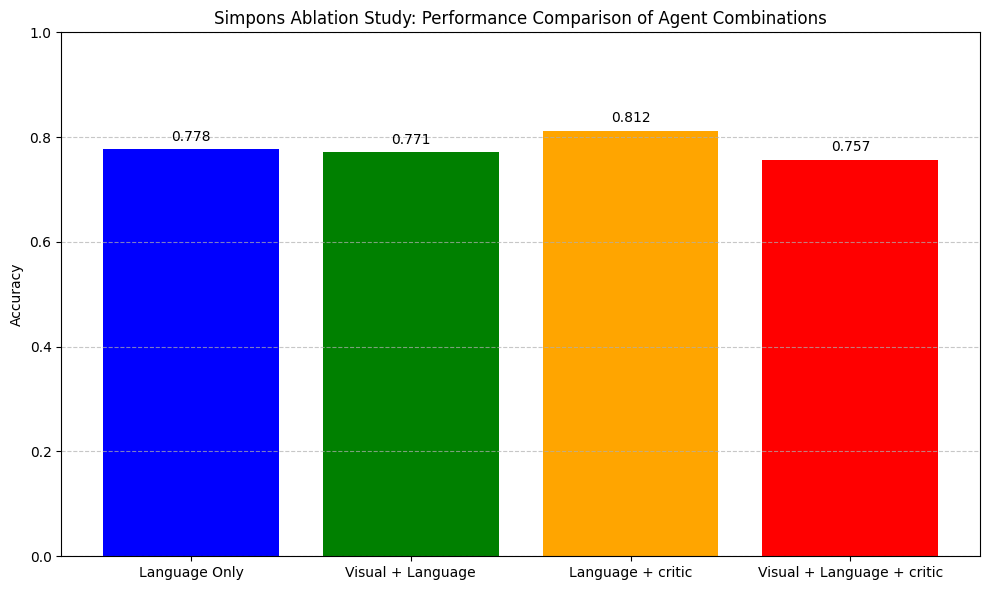


Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/Simpons_ablation_comparison.csv
Final comparison data:
                Configuration  Accuracy
0               Language Only  0.777778
1           Visual + Language  0.770833
2           Language + critic  0.812500
3  Visual + Language + critic  0.756944


In [101]:
# Create visualization of ablation results
# Check if all_accuracies has values - if not, try to load them from CSV files
if not all_accuracies:
    print("No accuracy results in memory. Attempting to load from CSV files...")
    
    # Define configuration names we expect to find
    expected_configs = [
        'language', 
        'visual_language', 
        'language_critic', 
        'visual_language_critic'
    ]
    
    # Safe model name for file pattern matching
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), os.path.join(results_dir, "ablation"))
    
    # Load accuracies from CSV files if they exist
    for config in expected_configs:
        file_path = os.path.join(results_dir, f'simpsons_ablation_{config}_{safe_model_name}.csv')
        try:
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                # Get the last row which should be the Average row
                avg_row = df[df['question_id'] == 'Average']
                if not avg_row.empty and 'accuracy' in avg_row.columns:
                    all_accuracies[config] = float(avg_row['accuracy'].iloc[0])
                    print(f"Loaded accuracy for {config}: {all_accuracies[config]:.4f}")
                else:
                    # Calculate average from individual rows
                    regular_rows = df[df['question_id'] != 'Average']
                    if not regular_rows.empty and 'accuracy' in regular_rows.columns:
                        all_accuracies[config] = float(regular_rows['accuracy'].mean())
                        print(f"Calculated accuracy for {config}: {all_accuracies[config]:.4f}")
        except Exception as e:
            print(f"Error loading results for {config}: {e}")

# If we still don't have accuracy values, use the ones from the notebook state
# or use placeholder values for demonstration
if not all_accuracies and 'accuracies' in globals() and accuracies:
    # Use the current experiment's results if available
    avg_accuracy = np.mean(accuracies) if accuracies else 0
    config_name = ''
    if ENABLE_VISUAL_AGENT:
        config_name += 'visual_'
    if ENABLE_LANGUAGE_AGENT:
        config_name += 'language'
    if ENABLE_CRITIC_AGENT:
        config_name += '_critic'
    
    if config_name:
        all_accuracies[config_name] = avg_accuracy
        print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

# Create the results dictionary for visualization
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + critic": all_accuracies.get('language_critic', 0),
    "Visual + Language + critic": all_accuracies.get('visual_language_critic', 0)
}

# Print the values we're using
print("\nAccuracy values used for visualization:")
for config, accuracy in results.items():
    print(f"{config}: {accuracy:.4f}")

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Simpons Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Save the comparison results to CSV
comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
comparison_path = os.path.join(os.getcwd(), "results", "ablation", "Simpons_ablation_comparison.csv")

# Create results directory if it doesn't exist
os.makedirs(os.path.dirname(comparison_path), exist_ok=True)

# Save the comparison file
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison results saved to: {comparison_path}")
print(f"Final comparison data:\n{comparison_df}")